# Diffusion on the edge - Part II: Maximal manifold exploration

In the previous part, we explored the basics of score-matching based diffusion models and continous-time stochastic processes.  
This follow up piece will walk through the basic ideas explored in the paper __paper_name_here__.

## Main concept

The paper introduces the concept of exploring the data manifold maximally by fine tuning a pre-learned diffusion model. Mathematically, the paper describes how diffusion models can miss some of the underlying data distribution. Our goal is to implement the described S-MEME algorithm and generate samples from low-density regions of the data manifold.

## Dataset

For simplicity, as we develop this implementation code we should have a simple and robust dataset on hand. 

Let's take as our fundamental data manifold all possible 2D-triangles based on distance. So each data point is a triplet of numbers, $(a, b, c)$ where the measurements $a, b, c$ are distances between points $A, B, C$ defined as $a = |AB|, b = |BC|, c = |CA|$. All of these points lie on some non-trivial submanifold of $\mathbb{R}^3$. For simplicity, let's also constrict the distances to be less than $1$. Therefore, the possible data points lie as a subset of the unit cube, $(a, b, c) \in [0, 1]^3$.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from diffusion_on_the_edge.stochastics.stochastics import generate_trajectory
from diffusion_on_the_edge.visualize import plot_multiple_1d_trajectories
from diffusion_on_the_edge.model import SimpleScoreNet
from diffusion_on_the_edge.ou_dataset import OUDiffusionDatasetVectorized 
from diffusion_on_the_edge.training import train_scorenet, TrainConfig

In [2]:
# Diffusion model parameters
lambda_coeff = 0.3
sigma_coeff = 0.5
def f_fn_torch(x, t): return -lambda_coeff * x
def g_fn_torch(t_scalar): return sigma_coeff

# Dataset sizes
B, D = 4096, 3

# Discretization parameters
delta_t = 0.01

In [3]:
def sample_valid_triangle_sides(n_samples: int, seed: int = 42, sort_sides = True):
    """Sample valid triangle side lengths (a, b, c) in [0, 1] satisfying the triangle inequality."""
    np.random.seed(seed)
    samples = []
    while len(samples) < n_samples:
        a, b, c = np.random.rand(3)
        if (a + b > c) and (b + c > a) and (c + a > b):
            sample = tuple(sorted((a, b, c))) if sort_sides else (a, b, c)
            samples.append(sample)
    return np.array(samples)

def classify_triangle_sides(a, b, c, tol=1e-2):
    """Classify triangle type by side lengths: 'equilateral', 'isosceles', or 'scalene'."""
    sides = sorted([a, b, c])
    if np.isclose(sides[0], sides[1], atol=tol) and np.isclose(sides[1], sides[2], atol=tol):
        return 'equilateral'
    elif np.isclose(sides[0], sides[1], atol=tol) or np.isclose(sides[1], sides[2], atol=tol):
        return 'isosceles'
    else:
        return 'scalene'

def classify_triangle_angles(a, b, c, tol=1e-2):
    """Classify triangle type by angles: 'right', 'acute', or 'obtuse'."""
    sides = sorted([a, b, c])  # ensure c is the longest side
    a, b, c = sides
    cos_C = (a**2 + b**2 - c**2) / (2 * a * b)
    cos_C = np.clip(cos_C, -1, 1)  # numerical stability
    angle_C = np.arccos(cos_C) * 180 / np.pi  # degrees
    if np.isclose(angle_C, 90.0, atol=tol * 90):
        return 'right'
    elif angle_C < 90:
        return 'acute'
    else:
        return 'obtuse'

def generate_biased_triangle_dataset(n_samples=5000, side_bias=None, angle_bias=None, seed=42):
    """
    Generate a dataset of triangle side lengths with optional bias on side and angle types.
    side_bias: dict like {'equilateral': 0.02, 'isosceles': 0.18, 'scalene': 0.80}
    angle_bias: dict like {'right': 0.05, 'acute': 0.70, 'obtuse': 0.25}
    """
    all_samples = sample_valid_triangle_sides(n_samples * 5, seed=seed)
    df = pd.DataFrame(all_samples, columns=['a', 'b', 'c'])
    df['side_type'] = df.apply(lambda row: classify_triangle_sides(row['a'], row['b'], row['c']), axis=1)
    df['angle_type'] = df.apply(lambda row: classify_triangle_angles(row['a'], row['b'], row['c']), axis=1)
    
    if side_bias:
        biased_df = []
        for ttype, ratio in side_bias.items():
            subset = df[df['side_type'] == ttype]
            n_target = int(n_samples * ratio)
            sampled_subset = subset.sample(n=min(n_target, len(subset)), random_state=seed)
            biased_df.append(sampled_subset)
        df = pd.concat(biased_df)
    
    if angle_bias:
        biased_df = []
        for atype, ratio in angle_bias.items():
            subset = df[df['angle_type'] == atype]
            n_target = int(n_samples * ratio)
            sampled_subset = subset.sample(n=min(n_target, len(subset)), random_state=seed)
            biased_df.append(sampled_subset)
        df = pd.concat(biased_df)

    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

In [4]:
# Generate dataset with both side and angle biases
dataset_df = generate_biased_triangle_dataset(
    n_samples=B,
    side_bias={'equilateral': 0.00, 'isosceles': 0.05, 'scalene': 0.90},
    angle_bias={'right': 0.00, 'acute': 0.70, 'obtuse': 0.3}
)
print(dataset_df.shape)
print(dataset_df.head())

(2764, 5)
          a         b         c  side_type angle_type
0  0.147467  0.646402  0.674394    scalene     obtuse
1  0.587415  0.855314  0.889092    scalene      acute
2  0.064907  0.388161  0.391228  isosceles      acute
3  0.295147  0.444009  0.680752    scalene     obtuse
4  0.561614  0.612428  0.741201    scalene      acute


Next, we can take a look at our generated dataset of triangles.

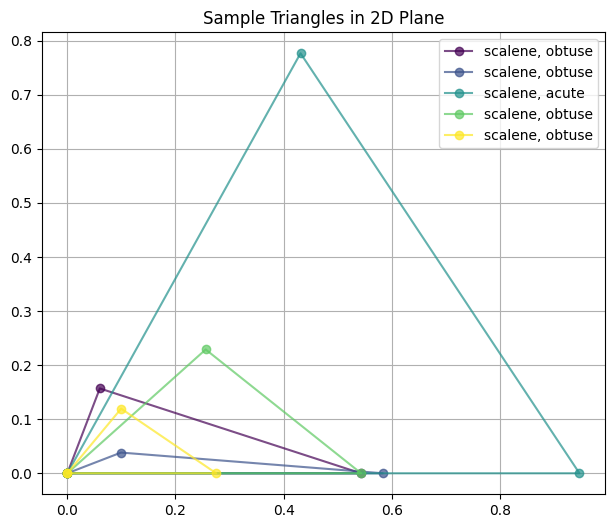

In [5]:
import matplotlib.pyplot as plt

def plot_triangle(a, b, c, ax, label=None, color='blue'):
    """
    Plot a triangle in 2D given side lengths a, b, c.
    Triangle ABC with:
        A at (0, 0),
        B at (c, 0),
        C determined by cosine law from a, b, c
    """
    # Fixed base AB
    A = np.array([0, 0])
    B = np.array([c, 0])
    
    # Use law of cosines to find angle at C
    cos_angle = (a**2 + c**2 - b**2) / (2 * a * c)
    cos_angle = np.clip(cos_angle, -1, 1)  # numerical safety
    angle = np.arccos(cos_angle)
    
    # Coordinates of C using polar transformation from A
    C = np.array([a * np.cos(angle), a * np.sin(angle)])
    
    triangle = np.array([A, B, C, A])
    ax.plot(triangle[:, 0], triangle[:, 1], marker='o', color=color, label=label, alpha = 0.7)
    ax.set_aspect('equal')

def visualize_sample_triangles(df, n=5):
    """
    Visualize n triangles from the dataframe.
    """
    _, ax = plt.subplots(figsize=(12, 6))
    sample = df.sample(n=n)
    colors = plt.cm.viridis(np.linspace(0, 1, n))
    
    for i, row in enumerate(sample.itertuples()):
        plot_triangle(row.a, row.b, row.c, ax, label=f"{row.side_type}, {row.angle_type}", color=colors[i])
    
    ax.legend()
    ax.set_title("Sample Triangles in 2D Plane")
    plt.grid(True)
    plt.show()

# Visualize a few triangles
visualize_sample_triangles(dataset_df, n=5)


Now we have a good understanding of our dataset, finally in this section we define an appropriate PyTorch dataset and -loader.  
Then, in the next section, we will focus on the actual diffusion model.

## Diffusion model

We will utilize a similar OU diffusion process for our diffusion model as in the first post.   
In this post we mainly skip the modeling parts and focus on fine tuning our trained model, therefore we shall use code stored in a separate python module to do the heavy lifting for us.

In [6]:
# Generating a sample and visualize it
sample = generate_trajectory(initial_pos=dataset_df[['a', 'b', 'c']].values, delta_t = 0.001, t = 1.0, f = lambda x, t: -lambda_coeff * x, g= lambda t: sigma_coeff)
trajectory = np.asarray([s[0] for s in sample])

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Multiple 1D Diffusion Trajectories'}, xlabel='Time', ylabel='x(t)'>)

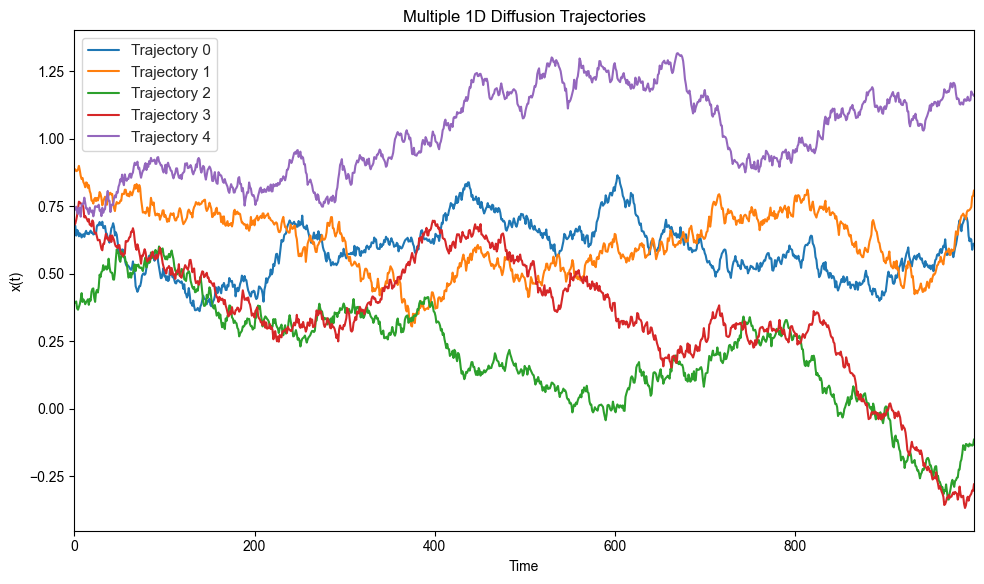

In [7]:
plot_multiple_1d_trajectories(trajectory[:, :5, 2])

### Training dataset

Now we define an iterable dataset for the diffusion model, the dataset contains tuples $(x, t, \nabla_x p_t(x))$.  
In other words, the iterable dataset generates samples $x \sim X_t$ from the diffusion process from the starting set of triangles. Alonside the samples, we compute the correct value for the gradient of the density $p_t(x)$.

In [ ]:
scaled_dataset = dataset_df[['a', 'b', 'c']].to_numpy()
scaled_dataset = 2 * scaled_dataset - 1 # Scale to -1, 1 range
scaled_dataset_torch = torch.from_numpy(scaled_dataset)

print(scaled_dataset.max())
print(scaled_dataset.min())
print(scaled_dataset.mean())

dataset = OUDiffusionDatasetVectorized(
    scaled_dataset_torch,
    T_max=1.0,
    lam = lambda_coeff,
    sigma = sigma_coeff,
    batch_size=16,
    batches_per_epoch=100
)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=None)

0.9998793920914371
-0.9854375947033431
0.18288661797684305


dict_keys(['t', 'x0', 'xt', 'mean', 'var', 'score'])

In [9]:
# Defining a model
model = SimpleScoreNet(input_dimension=3, layer_count=2, hidden_dim=256)

In [10]:
# Train the scoring model on the triangle dataset
config = TrainConfig(epochs=16, lr=0.01)
train_result = train_scorenet(model, dataloader, cfg=config)
train_result

Epoch 1/16: 100it [00:00, 879.89it/s, loss=7.57]


Epoch 1: avg loss = 7.573209


Epoch 2/16: 100it [00:00, 1135.00it/s, loss=5.8]


Epoch 2: avg loss = 5.799601


Epoch 3/16: 100it [00:00, 1137.90it/s, loss=5.16]


...

Epoch 15/16: 100it [00:00, 1127.86it/s, loss=4.47]


Epoch 15: avg loss = 4.468581


Epoch 16/16: 100it [00:00, 1138.69it/s, loss=4.6]


Epoch 16: avg loss = 4.601637


{'model': SimpleScoreNet(
   (time_emb): SinusoidalTimeEmbedding()
   (net): Sequential(
     (0): Linear(in_features=67, out_features=256, bias=True)
     (1): SiLU(inplace=True)
     (2): Linear(in_features=256, out_features=256, bias=True)
     (3): SiLU(inplace=True)
     (4): Linear(in_features=256, out_features=3, bias=True)
   )
 ),
 'losses': [7.573208830356598,
  5.799601106643677,
  5.158975734710693,
  4.924901328086853,
  5.011137225627899,
  5.081344237327576,
  5.072366107702255,
  4.607092332839966,
  4.54018070936203,
  4.753385338783264,
  4.610771543979645,
  4.784706213474274,
  4.4412019515037535,
  4.340211046934128,
  4.468580951690674,
  4.601637442111969]}

### Backwards sampling

Now we have the model, we can sample backwards as in the introduction post.

In [ ]:
from diffusion_on_the_edge.stochastics.backwards_stochastics import reverse_pc_sampler_torch

In [12]:

# Generate random samples
x_T = torch.randn(B, D).to('cpu')

# Get the trained model and put in 'eval' mode.
score_model: nn.Module = train_result.get('model')
score_model.to('cpu').eval()

# Generate new samples using backwards SDE
samples = reverse_pc_sampler_torch(
    x_T=x_T,
    score_model=score_model,
    f_fn=f_fn_torch,
    g_fn=g_fn_torch,
    T=1.0,
    N=1000,
    snr=0.15,
)

samples_arr = samples.detach().cpu().numpy()

In [13]:
def valid_triangle(sides, eps = 1E-3):
    """
    Check whether or not a triangle with side lengths (a, b, c) is valid
    """
    a, b, c = sides
    if a < 0 or b < 0 or c < 0:
        return False
    sorted_sides = sorted((a, b, c))
    return sorted_sides[0] + sorted_sides[1] - eps >= sorted_sides[2]

In [14]:
def triangle_validity_numpy(x_prescaled: np.ndarray, eps: float = 1e-6):
    """
    x: (N,3) array of side lengths
    Returns dict with masks and counts.
    """
    assert x_prescaled.shape[1] == 3, "Expected shape (N,3) for triangles"
    N = x_prescaled.shape[0]

    # Scale x back to original
    x = (x_prescaled + 1) / 2

    # Basic range checks
    in_range = (x >= -eps).all(axis=1) & (x <= 1.0 + eps).all(axis=1)
    neg_mask  = (x < -eps).any(axis=1)
    over1_mask = (x > 1.0 + eps).any(axis=1)

    # Sort so that a <= b <= c
    xs = np.sort(x, axis=1)
    a, b, c = xs[:,0], xs[:,1], xs[:,2]

    # Triangle inequality (with margin)
    triangle_ok = (c <= a + b - eps)

    # Combined validity
    valid = in_range & triangle_ok

    return {
        "valid_mask": valid,
        "invalid_mask": ~valid,
        "in_range_mask": in_range,
        "triangle_ok_mask": triangle_ok,
        "neg_mask": neg_mask,
        "over1_mask": over1_mask,
        "violates_triangle_mask": ~triangle_ok,
        "sorted_x": xs,
        "counts": {
            "N": N,
            "valid": int(valid.sum()),
            "invalid": int((~valid).sum()),
            "neg": int(neg_mask.sum()),
            "over1": int(over1_mask.sum()),
            "triangle_violations": int((~triangle_ok).sum()),
        }
    }

def print_triangle_summary(res):
    c = res["counts"]
    N = c["N"]
    pct = lambda n: 100.0 * n / max(1, N)
    print(f"Total: {N}")
    print(f"Valid: {c['valid']} ({pct(c['valid']):.2f}%)")
    print(f"Invalid: {c['invalid']} ({pct(c['invalid']):.2f}%)")
    print(f"Rejection reason counts:")
    print(f"  Negative <0: {c['neg']} ({pct(c['neg']):.2f}%)")
    print(f"  >1: {c['over1']} ({pct(c['over1']):.2f}%)")
    print(f"  Triangle inequality fail: {c['triangle_violations']} ({pct(c['triangle_violations']):.2f}%)")


In [15]:
# Suppose samples is your (N,3) NumPy array
res = triangle_validity_numpy(samples_arr, eps = 1E-3)
print_triangle_summary(res)

valid_samples = samples[res["valid_mask"]]
invalid_samples = samples[res["invalid_mask"]]

Total: 4096
Valid: 3649 (89.09%)
Invalid: 447 (10.91%)
Rejection reason counts:
  Negative <0: 19 (0.46%)
  >1: 173 (4.22%)
  Triangle inequality fail: 293 (7.15%)


### Original model conclusion

Now we have a model with sufficient capability of generating valid triangles with some accuracy.  
Our score function model is not perfect but it captures nicely the different 

In [16]:
inverse_transform_samples = (samples.numpy() + 1) / 2
generated_df = pd.DataFrame(inverse_transform_samples, columns=['a', 'b', 'c'])
generated_df['side_type'] = 'gen'
generated_df['angle_type'] = 'gen'
generated_df['valid'] = res['valid_mask']

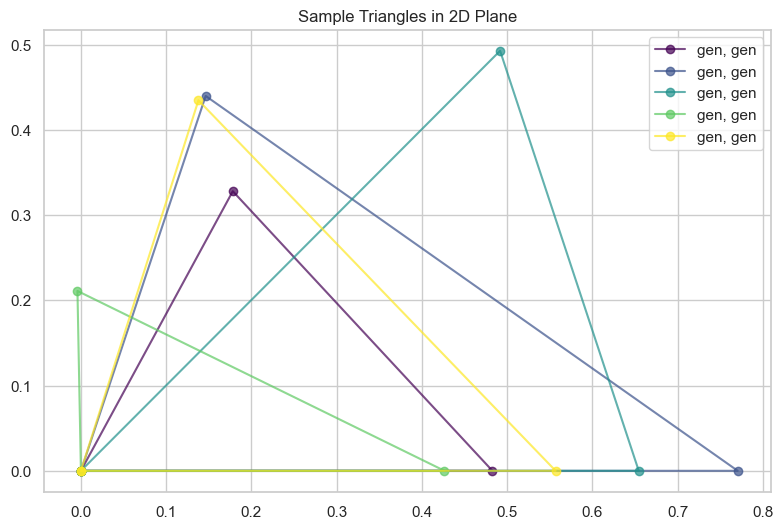

In [17]:
visualize_sample_triangles(generated_df[generated_df['valid']])

From the above plot, we can see that our model has generated some nice triangles for us.  
We can also take a look at the invalid samples and see where they went wrong.

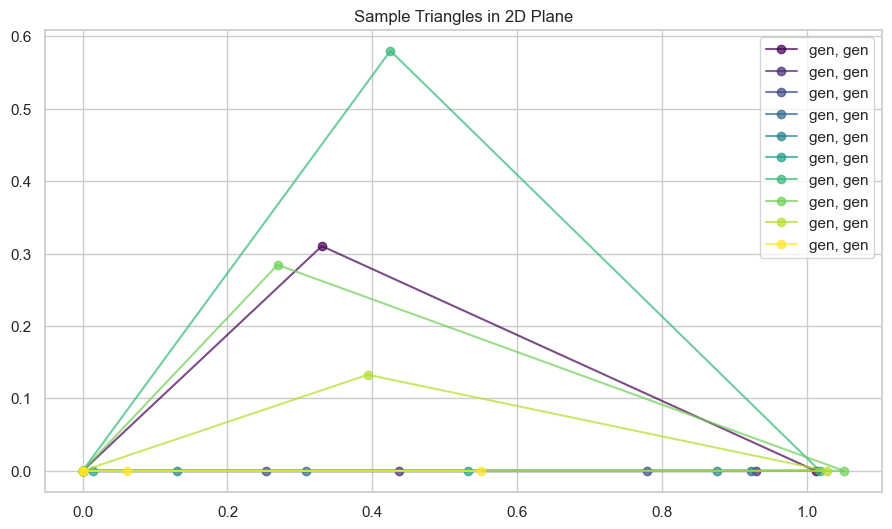

In [18]:
visualize_sample_triangles(generated_df[~generated_df['valid']], n = 10)

Easily we can see that some of the samples are either degenerate with some side being approximately $0$, or they break the boundary length of $1$.

# Maximal manifold exploration

Now we have the basic setup ready, we have a pretuned model $s^\text{pre}$ which is capable of generating valid triangles.  
Turning our attention to the manifold $\mathcal{T}$, we have the goal of exploring some of the uncommon triangles and seeing if we can find some quite niche samples.

## Maximal exploration formalism

The punchline of the paper is the following: we can fine-tune an already trained model $s^\text{pre}$ to find those uncommon samples by adjusting the model. More formally, given a pre-learned model (policy) $\pi^\text{pre}$, we want to learn a new model $\pi$ such that

$$
\begin{align}
\pi &= \arg\max_{\pi} \ \mathcal{H}(p^\pi_T) \\
p^{\pi}_T &\in \mathbb{P}(\Omega_\text{pre}) \\
\end{align}
$$

is satisfied. Here $\mathcal{H}(p^\pi_T)$ denotes the entropy of the marginal density $p^\pi_T$, and the constraint ensures that $p^\pi_T$ lies within the support $\Omega_\text{pre}$ of the original pre-trained model’s distribution.

In essence, this captures the idea of learning a distribution that maximizes entropy—spreading probability mass as uniformly as possible—while remaining within the “valid” region $\Omega_\text{pre}$ defined by the pre-trained model.

### The first variation and surprise

Optimizing entropy directly is difficult since it is a nonlinear functional of the distribution.   
The key insight of the paper is to look at the first variation of entropy, which is linear and therefore tractable. The entropy variation evaluated at the pre-trained distribution is 

$$\delta \mathcal{H}(p^\text{pre}_T)(x) = -\log p^\text{pre}_T(x)$$

which can be interpreted as a surprise signal. 
The variation makes it so samples that were unlikely under the original model are weighted highly. Thus, the fine-tuning problem can be rewritten as

$$
\pi^\ast = \arg\max_{\pi} \ \mathbb{E}_{x \sim \pi}\big[ -\log p^\text{pre}_T(x) \big] \ - \ \alpha \, D_{\text{KL}}\!\left(p^\pi_T \;\|\; p^\text{pre}_T \right),
$$

where the Kullback–Leibler regularization, $D_{\text{KL}}$, ensures that the fine-tuned policy does not drift too far and remains supported on $\Omega_\text{pre}$.

#### Optional background: functionals and variations

In general, a variation is a concept from (surprise, surprise) *calculus of variations*. It is a generalization of the derivative, but instead of taking derivatives of functions, we take derivatives of functionals. A functional is a map from a space of functions into the real numbers, $\mathcal{F}: \mathcal{X} \to \mathbb{R}$ where $f \in \mathcal{X} \mapsto \mathcal{F}(f) \in \mathbb{R}$.

For example, evaluating a definite integral of an integrable function $f$ is a functional, $\mathcal{F}[f] = \int_a^b f(x)dx$. The first variation of $\mathcal{F}$ at $f$ in the direction of a perturbation $\eta(x)$ is defined as

$$
\delta \mathcal{F}[f; \eta] 
= \left.\frac{d}{d\epsilon} \, \mathcal{F}[f + \epsilon \eta] \right|_{\epsilon = 0}.
$$

Here $\epsilon$ is a small parameter. Like with directional derivatives in multivariate calculus, this is exactly the infinite-dimensional analogue.


### The crucial realization: no density estimation needed

Naively, this would require estimating $p^\text{pre}_T(x)$, which is infeasible in high dimensions. The breakthrough of the paper is recognizing that the gradient of the entropy variation is exactly equal to the negative score

$$
\nabla_x \delta \mathcal{H}(p^\pi_T) \;=\; - \nabla_x \log p^\pi_T(x) \;\approx\; - s^\pi(x, T),
$$

where $s^\pi$ is the score function. For more details, please refer to the original paper _paper name here_.

## Conclusion

This means that instead of explicitly computing densities, we can use the score network itself to provide the update direction for entropy maximization. Fine-tuning reduces to an iterative process where the pre-trained score model supplies the gradient information needed to explore low-density regions.


## Implementation of manifold exploration in practice

The practical implementation of the fine tuning approach is done by having a loss function, with $3$ different components
- score matching $(s_k(x, t) - s^*(x, t))^2$
- close distance $(s_{k}(x, t) - s_{k - 1}(x, t))^2$ 
- tuning to direction of negative score $\left<\Delta s_k(x, t), -s_{k - 1}(x, t)\right>$

Adding these different loss components we obtain the total loss which is then minimized in a "student & teacher"-style mirror gradient-descent algorithm.

In [19]:
from diffusion_on_the_edge.tuning_model import build_teacher_student
from diffusion_on_the_edge.tuning_tracker import TuningTracker 

In [20]:
teacher_tuning, student_tuning = build_teacher_student(pretrained_score_model=score_model, hidden_size=64)
tracker = TuningTracker(
    log_name="triangle_tuning",
    use_tensorboard=True,
    write_csv=True
)

In [21]:
INNER_EPOCHS = 10
OUTER_EPOCHS = 5

beta = 0.9
lambda_prox = 0.2

BATCH_SIZE = 256
DATASET_SIZE = 2 ** 10

def is_valid_triangle_torch(x_prescaled: torch.Tensor):
    x = (x_prescaled + 1) / 2
    # x: [B,3], works on any device
    a, b, c = torch.sort(x, dim=1).values.unbind(dim=1)
    return (a + b > c) & (a + c > b) & (b + c > a)

optimizer = torch.optim.AdamW(student_tuning.delta.parameters(), lr = 0.0001)

# Tuning loop
for epoch in range(OUTER_EPOCHS):
    # Generate new samples using score model
    x_T = torch.randn(size=(DATASET_SIZE, 3))
    with torch.no_grad():
        samples = reverse_pc_sampler_torch(
            x_T=x_T,
            score_model=student_tuning,
            f_fn=f_fn_torch,
            g_fn=g_fn_torch,
            T=1.0,
            N=1000,
            snr=0.15,
        )

    # Check valid triangles
    validity_result = is_valid_triangle_torch(x_prescaled=samples)
    valid_samples = samples[validity_result]

    # Log sampler validity + triangle margins for this outer epoch
    tracker.on_outer_epoch_start(epoch, samples, validity_result)

    generated_dataset = OUDiffusionDatasetVectorized(
        x0_pool=valid_samples.detach(),
        T_max=1.0, 
        lam=lambda_coeff, 
        sigma=sigma_coeff, 
        batch_size=BATCH_SIZE,
        batches_per_epoch=max(1, valid_samples.shape[0] // BATCH_SIZE),
    )
    
    generated_dataloader = torch.utils.data.DataLoader(generated_dataset, batch_size=None)
    teacher_tuning.load_state_dict(student_tuning.state_dict())
    teacher_tuning.eval()
    student_tuning.train()

    # Inner loop
    losses = []
    for inner_epoch in range(INNER_EPOCHS):
        for batch in generated_dataloader:
            optimizer.zero_grad()

            # Get training elements
            t = batch.get('t')
            x = batch.get('xt')
            score = batch.get('score')

            # Forward pass to tuning models
            student_prediction = student_tuning(x, t)
            with torch.no_grad():
                teacher_prediction = score_model(x, t)

            delta = student_prediction - teacher_prediction
            delta_ratio = (student_prediction - teacher_prediction).norm() / teacher_prediction.norm()
            delta_loss = lambda_prox * torch.sum(delta ** 2, dim = 1).mean()

            # Score loss
            omega = batch.get('var').clamp(min=1E-3, max = 10.0)
            omega = omega / omega.mean()
            score_loss = torch.sum((score - student_prediction) ** 2, dim = 1)
            score_loss = torch.mean(omega * score_loss)

            direction_loss = beta * torch.sum(-teacher_prediction * delta, dim = 1).mean()
            loss = score_loss + delta_loss - direction_loss
            loss.backward()
            optimizer.step()

            tracker.log_train_step(
                outer_epoch=epoch,
                inner_epoch=inner_epoch,
                student=student_tuning,
                optimizer=optimizer,
                batch_t=t,
                teacher_pred=teacher_prediction,
                student_pred=student_prediction,
                loss_dict={
                    "loss": loss,
                    "score_loss": score_loss,
                    "delta_loss": delta_loss,
                    "direction_loss": direction_loss,
                },
            )
            losses.append([x_.detach().cpu().numpy() for x_ in [loss, score_loss, delta_loss, direction_loss]])

        tracker.on_inner_epoch_end(outer_epoch=epoch, inner_epoch=inner_epoch)
    losses = np.asarray(losses)
    tracker.on_outer_epoch_end(epoch)
tracker.close()


[outer 0] generated 1024 samples | valid: 948 (0.926) | avg_margin: 0.3168 | min_margin: 0.0007
[outer 0 | inner 0] loss 109.2895 | score 109.4584 | Δ/teach 0.049 | cos(-T,Δ) 0.182
[outer 0 | inner 1] loss 120.6547 | score 120.8501 | Δ/teach 0.051 | cos(-T,Δ) 0.199
[outer 0 | inner 2] loss 181.4434 | score 181.6182 | Δ/teach 0.048 | cos(-T,Δ) 0.170
[outer 0 | inner 3] loss 67.4070 | score 67.6522 | Δ/teach 0.049 | cos(-T,Δ) 0.221
[outer 0 | inner 4] loss 95.7018 | score 95.9214 | Δ/teach 0.052 | cos(-T,Δ) 0.204
[outer 0 | inner 5] loss 3261.2801 | score 3261.5340 | Δ/teach 0.053 | cos(-T,Δ) 0.222
[outer 0 | inner 6] loss 178.1331 | score 178.3406 | Δ/teach 0.053 | cos(-T,Δ) 0.177
[outer 0 | inner 7] loss 84.7533 | score 84.9580 | Δ/teach 0.054 | cos(-T,Δ) 0.183
[outer 0 | inner 8] loss 71.2042 | score 71.4049 | Δ/teach 0.053 | cos(-T,Δ) 0.187
[outer 0 | inner 9] loss 75.5122 | score 75.7268 | Δ/teach 0.055 | cos(-T,Δ) 0.179
[outer 0] finished in 0.2s

[outer 1] generated 1024 samples |

## Fine-tuned model sampling

Now we have a fine-tuned model $\pi^*$. Utilizing it, we can sample now triangles which are underreprensented or even not found at all in the original dataset.

We begin by sampling from the tuned dataset and examining how many of our new samples are valid.

In [22]:
samples_tuned = reverse_pc_sampler_torch(
    x_T=x_T, # Note: We use the same input sample as the original model
    score_model=student_tuning,
    f_fn=f_fn_torch,
    g_fn=g_fn_torch,
    T=1.0,
    N=1000,
    snr=0.15,
)

samples_arr_tuned = samples_tuned.detach().cpu().numpy()

In [23]:
res_tuned = triangle_validity_numpy(samples_arr_tuned, eps = 1E-3)
print_triangle_summary(res_tuned)

valid_tuned_samples = samples_arr_tuned[res_tuned['valid_mask']]

Total: 1024
Valid: 928 (90.62%)
Invalid: 96 (9.38%)
Rejection reason counts:
  Negative <0: 4 (0.39%)
  >1: 30 (2.93%)
  Triangle inequality fail: 69 (6.74%)


### Visualization

We have a nice proportion of valid triangles, we can visualize them in a similar way.  
By creating a mapping from the side lengths $(a, b, c)$ into a shape $(u, v, 1)$ by a simple transformation, $u = x/c, v = y/c$, we can visualize the space of triangles as a submanifold of $\mathbb{R}^2$. 

The score fields themselves can also be visualized, noting how different the original model is from the fine-tuned one.

In [24]:
def mapping_uv(triangles_normalized: np.ndarray, c_coeff:float = 1.0) -> np.ndarray:
    triangles = (triangles_normalized + 1) / 2.0
    a, b, c = (triangles[:, 0], triangles[:, 1], triangles[:, 2])
    u = a / c
    v = b / c
    return np.column_stack([u, v, np.repeat(1, triangles.shape[0]) * c_coeff])

In [25]:
uv_original_samples = mapping_uv(valid_samples.numpy())
uv_tuned_samples = mapping_uv(valid_tuned_samples)

[(0.0, 2.0), (0.0, 2.0), None]

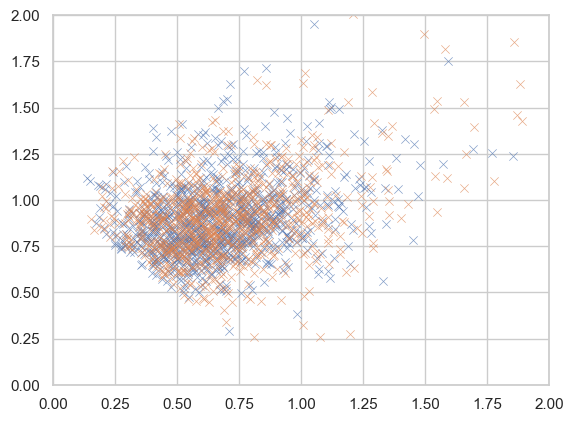

In [26]:
sns.scatterplot(x = uv_original_samples[:, 0], y = uv_original_samples[:, 1], alpha=0.7, marker='x').set(xlim=(0, 2), ylim=(0, 2), alpha = 0.3)
sns.scatterplot(x = uv_tuned_samples[:, 0], y = uv_tuned_samples[:, 1], alpha=0.7, marker='x').set(xlim=(0, 2), ylim=(0, 2), alpha = 0.3)